# Parte 1 - Análisis de la base de datos

Dataset elegido: Water potability.

Fuente: https://www.kaggle.com/datasets/adityakadiwal/water-potability

El objetivo de esta parte es analizar la base antes de usarla para entrenar una red neuronal de clasificación.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.shape

(3276, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
df.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [12]:
# PARTE 1C - Balance de clases
print("Distribución de la variable objetivo:")
print(df["Potability"].value_counts())
print("\nPorcentaje de cada clase:")
print(df["Potability"].value_counts(normalize=True) * 100)

Distribución de la variable objetivo:
Potability
0    1998
1    1278
Name: count, dtype: int64

Porcentaje de cada clase:
Potability
0    60.989011
1    39.010989
Name: proportion, dtype: float64


In [11]:
df_encoded = pd.get_dummies(df, drop_first=False)
df_encoded.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [13]:
correlaciones = df.corr(numeric_only=True)["Potability"].sort_values(ascending=False)
print(correlaciones)

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64


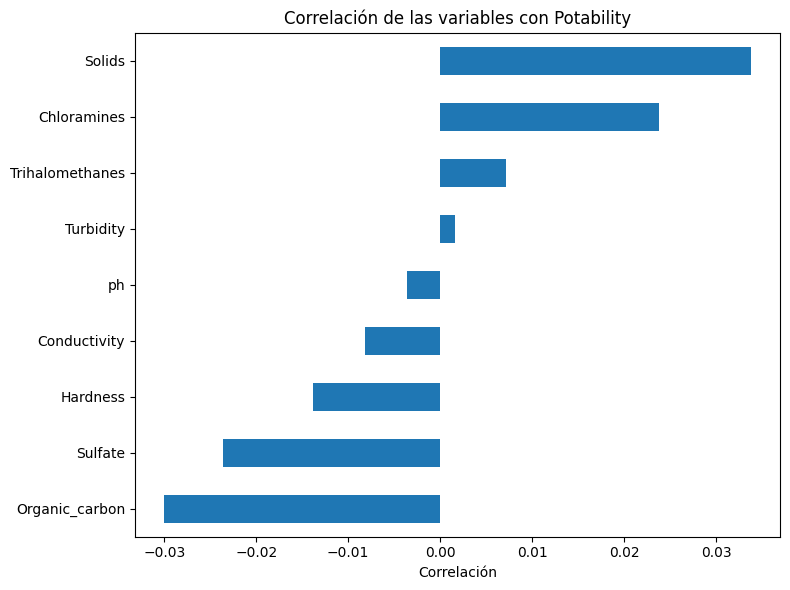

In [14]:
# Gráfico de correlaciones
plt.figure(figsize=(8, 6))
correlaciones.drop("Potability").sort_values().plot(kind="barh")
plt.title("Correlación de las variables con Potability")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

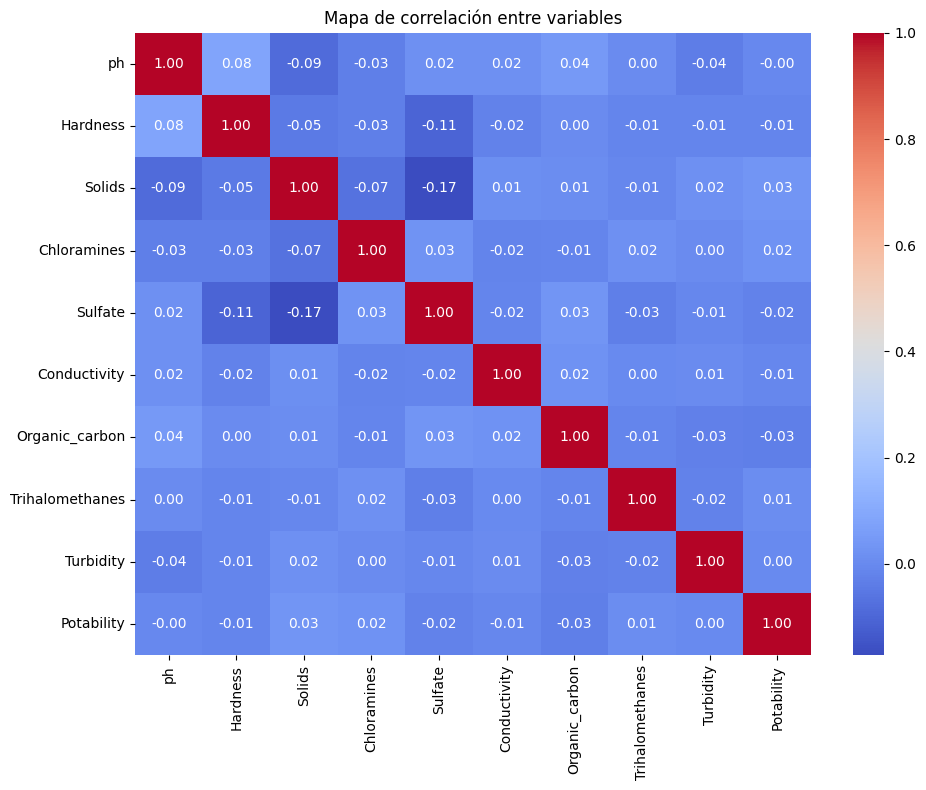

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación entre variables")
plt.tight_layout()
plt.show()

In [20]:
# D)
columnas_numericas = ["ph", "Hardness", "Solids", "Chloramines", 
                      "Sulfate", "Conductivity", "Organic_carbon", 
                      "Trihalomethanes", "Turbidity"]

def detectar_atipicos_iqr(data, columna):
    q1 = data[columna].quantile(0.25)
    q3 = data[columna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    atipicos = data[(data[columna] < limite_inferior) | (data[columna] > limite_superior)]
    return limite_inferior, limite_superior, len(atipicos)

for col in columnas_numericas:
    li, ls, cantidad = detectar_atipicos_iqr(df, col)
    print(f"{col}: lím. inferior={li:.2f}, lím. superior={ls:.2f}, atípicos={cantidad}")

ph: lím. inferior=3.14, lím. superior=11.02, atípicos=46
Hardness: lím. inferior=117.13, lím. superior=276.39, atípicos=83
Solids: lím. inferior=-1832.42, lím. superior=44831.87, atípicos=47
Chloramines: lím. inferior=3.15, lím. superior=11.10, atípicos=61
Sulfate: lím. inferior=229.32, lím. superior=438.33, atípicos=41
Conductivity: lím. inferior=191.65, lím. superior=655.88, atípicos=11
Organic_carbon: lím. inferior=5.33, lím. superior=23.30, atípicos=25
Trihalomethanes: lím. inferior=23.61, lím. superior=109.58, atípicos=33
Turbidity: lím. inferior=1.85, lím. superior=6.09, atípicos=19


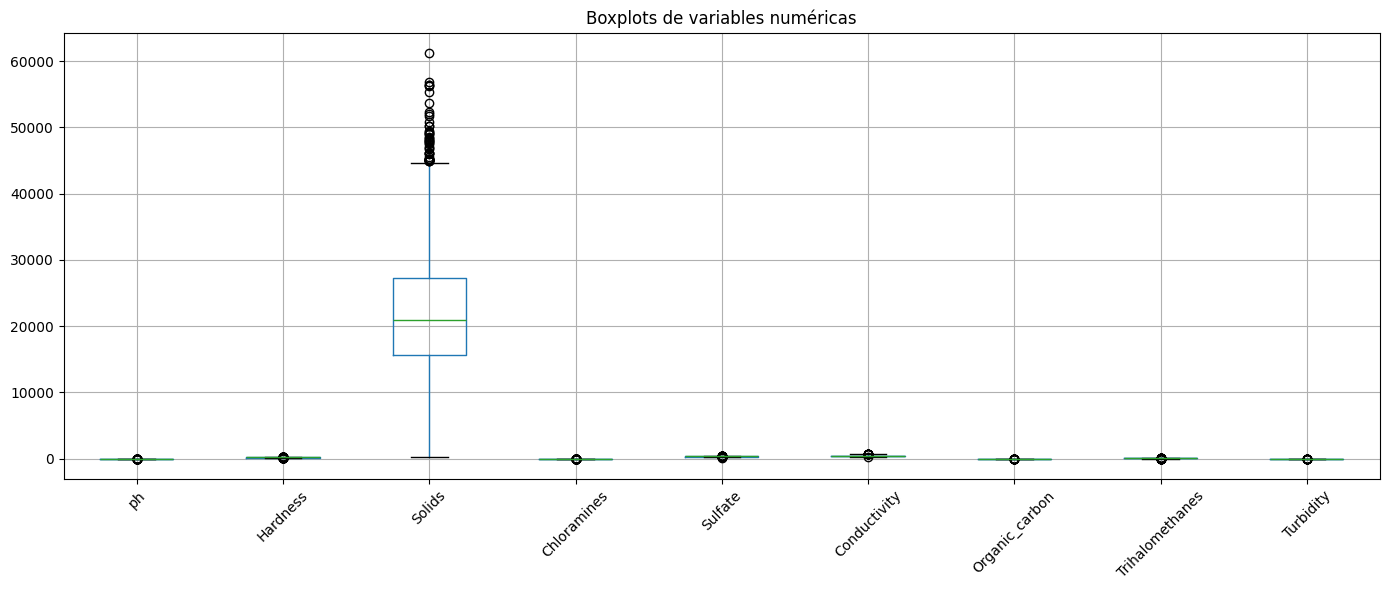

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
df[columnas_numericas].boxplot(ax=ax)
ax.set_title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

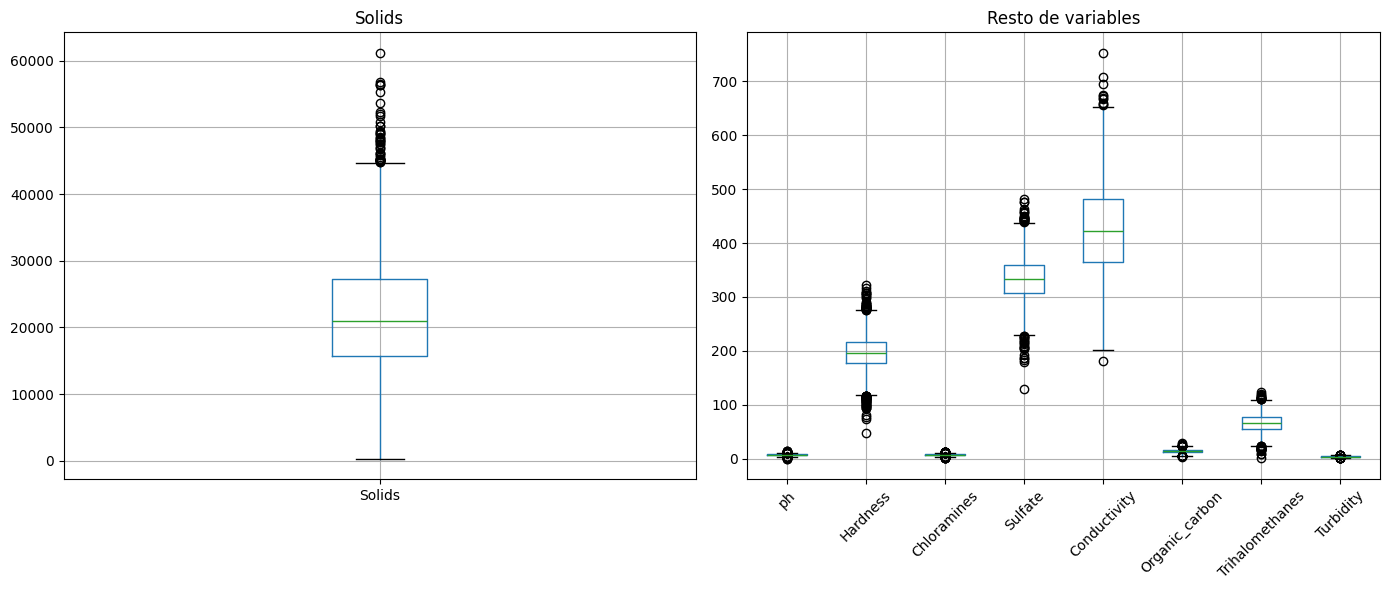

In [22]:
# Graficamos Solids aparte y el resto junto
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Solo Solids
df[["Solids"]].boxplot(ax=ax1)
ax1.set_title("Solids")

# El resto sin Solids
otras = ["ph", "Hardness", "Chloramines", "Sulfate", 
         "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]
df[otras].boxplot(ax=ax2)
ax2.set_title("Resto de variables")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Imputamos valores faltantes con la mediana
df_limpio = df.copy()
df_limpio["ph"] = df_limpio["ph"].fillna(df_limpio["ph"].median())
df_limpio["Sulfate"] = df_limpio["Sulfate"].fillna(df_limpio["Sulfate"].median())
df_limpio["Trihalomethanes"] = df_limpio["Trihalomethanes"].fillna(df_limpio["Trihalomethanes"].median())

print("Valores faltantes después de imputar:")
print(df_limpio.isnull().sum())

Valores faltantes después de imputar:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [25]:
# Separamos X e y
X_raw = df_limpio.drop(columns=["Potability"]).to_numpy()
y = df_limpio["Potability"].to_numpy().reshape(-1, 1)

# Aplicamos Z-score a todas las columnas
X = X_raw.astype(float)
for col in range(X.shape[1]):
    media = X[:, col].mean()
    desviacion = X[:, col].std()
    X[:, col] = (X[:, col] - media) / desviacion

print("Normalización completada")
print("Medias (deben ser ~0):", X.mean(axis=0).round(2))
print("Desviaciones (deben ser ~1):", X.std(axis=0).round(2))
print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nPrimera fila de X normalizada:", X[0].round(4))

Normalización completada
Medias (deben ser ~0): [ 0.  0. -0.  0. -0.  0.  0. -0.  0.]
Desviaciones (deben ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Shape X: (3276, 9)
Shape y: (3276, 1)

Primera fila de X normalizada: [-0.0255  0.2592 -0.1395  0.1124  0.966   1.709  -1.1807  1.3054 -1.2863]
